In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
%matplotlib inline

print("✅ All libraries imported!")


✅ All libraries imported!


In [3]:
df = pd.read_csv(r'C:\Users\Janhavi\ChurnProject\data\processed\telco_rfm.csv')
print("Shape:", df.shape)
df.head()


Shape: (7032, 26)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,R_Score,Service_Count,F_Score,M_Score,RFM_Score,Segment
0,Female,0,Yes,No,1,0,0,DSL,0,1,...,Electronic check,29.85,29.85,0,4,1,1,1,6,Loyal
1,Male,0,No,No,34,1,0,DSL,1,0,...,Mailed check,56.95,1889.50,0,2,3,2,3,7,Loyal
2,Male,0,No,No,2,1,0,DSL,1,1,...,Mailed check,53.85,108.15,1,4,3,2,1,7,Loyal
3,Male,0,No,No,45,0,0,DSL,1,0,...,Bank transfer (automatic),42.30,1840.75,0,2,3,2,3,7,Loyal
4,Female,0,No,No,2,1,0,Fiber optic,0,0,...,Electronic check,70.70,151.65,1,4,1,1,1,6,Loyal


In [4]:
# These columns contain words (text) - we convert them to numbers using One-Hot Encoding
nominal_cols = ['gender', 'Partner', 'Dependents', 
                'InternetService', 'Contract', 
                'PaymentMethod', 'PaperlessBilling',
                'Segment']

df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print(f"Columns before encoding: {df.shape[1]}")
print(f"Columns after encoding:  {df_encoded.shape[1]}")
print("✅ Encoding done!")


Columns before encoding: 26
Columns after encoding:  31
✅ Encoding done!


In [5]:
# X = everything the model uses to learn (the clues)
# y = what we want to predict (Churn: 0 or 1)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)
print(f"\nChurn distribution:\n{y.value_counts()}")


X shape: (7032, 30)
y shape: (7032,)

Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [6]:
# 80% to train, 20% to test
# stratify=y keeps the same churn ratio in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")


Training samples : 5625
Testing samples  : 1407


In [7]:
# Brings all columns to the same scale so no single column dominates

scaler = StandardScaler()

# Fit on training data only, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # ⚠️ transform only, never fit on test!

print("✅ Scaling done!")


✅ Scaling done!


In [8]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print("✅ Model trained!")
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


✅ Model trained!

ROC-AUC Score: 0.8327

=== Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1033
       Churn       0.62      0.55      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



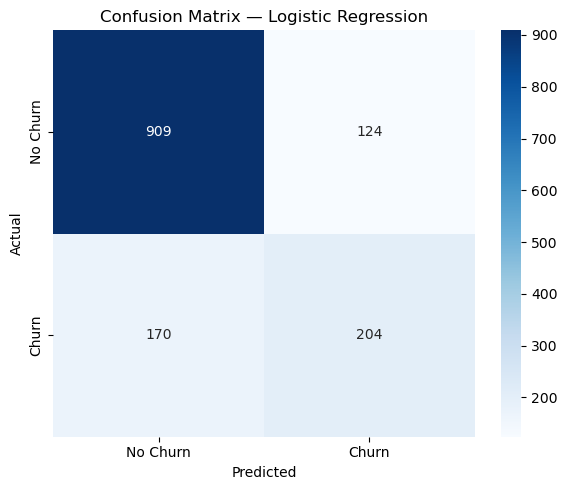

✅ Correctly caught churners   : 204
❌ Missed churners             : 170
❌ False alarms (not churners) : 124


In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(r'C:\Users\Janhavi\ChurnProject\reports\confusion_matrix.png')
plt.show()

print(f"✅ Correctly caught churners   : {cm[1][1]}")
print(f"❌ Missed churners             : {cm[1][0]}")
print(f"❌ False alarms (not churners) : {cm[0][1]}")


In [10]:
# Save the model and scaler so we can reuse them in the web app later
with open(r'C:\Users\Janhavi\ChurnProject\models\lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open(r'C:\Users\Janhavi\ChurnProject\models\scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save column names too — we'll need these in the web app
with open(r'C:\Users\Janhavi\ChurnProject\models\feature_columns.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print("✅ Model, scaler and feature columns saved!")


✅ Model, scaler and feature columns saved!


In [11]:
# Import three new model types to compare against Logistic Regression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# ===================== RANDOM FOREST =====================
# Random Forest builds MANY decision trees and combines their votes
# n_estimators=100 means it builds 100 trees
# random_state=42 makes results reproducible (same result every time you run)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# .fit() is where the actual learning happens — model studies X_train and y_train
rf_model.fit(X_train_scaled, y_train)

# .predict_proba() gives PROBABILITY of each class [prob_no_churn, prob_churn]
# [:, 1] means "take only the second column" = probability of churn
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# .predict() gives hard predictions: 0 or 1 (not probabilities)
rf_pred = rf_model.predict(X_test_scaled)

print("=== Random Forest ===")
# roc_auc_score compares our predicted probabilities against actual labels
print(f"ROC-AUC: {roc_auc_score(y_test, rf_prob):.4f}")
# classification_report shows precision, recall, f1 for each class
print(classification_report(y_test, rf_pred, target_names=['No Churn', 'Churn']))


# ===================== GRADIENT BOOSTING =====================
# Gradient Boosting also builds trees BUT one at a time
# Each new tree learns from the MISTAKES of the previous tree
# This makes it very accurate but slower to train
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_scaled, y_train)

# Same prediction process as Random Forest
gb_prob = gb_model.predict_proba(X_test_scaled)[:, 1]
gb_pred = gb_model.predict(X_test_scaled)

print("=== Gradient Boosting ===")
print(f"ROC-AUC: {roc_auc_score(y_test, gb_prob):.4f}")
print(classification_report(y_test, gb_pred, target_names=['No Churn', 'Churn']))


=== Random Forest ===
ROC-AUC: 0.8182
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1033
       Churn       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.72      1407
weighted avg       0.78      0.79      0.78      1407

=== Gradient Boosting ===
ROC-AUC: 0.8412
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1033
       Churn       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



              Model  ROC-AUC
  Gradient Boosting   0.8412
Logistic Regression   0.8327
      Random Forest   0.8182


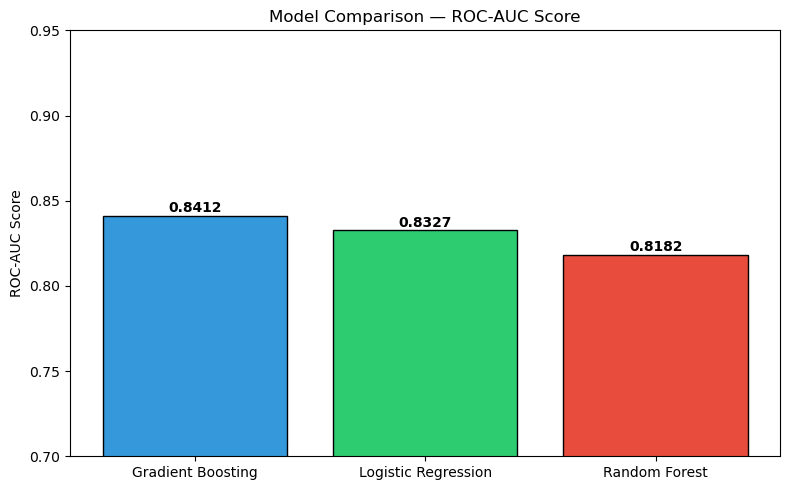

In [12]:
# Build a summary table of all models and their ROC-AUC scores
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'ROC-AUC': [
        # y_prob was from Logistic Regression (Cell 7)
        round(roc_auc_score(y_test, y_prob), 4),
        # rf_prob was from Random Forest (Cell 10)
        round(roc_auc_score(y_test, rf_prob), 4),
        # gb_prob was from Gradient Boosting (Cell 10)
        round(roc_auc_score(y_test, gb_prob), 4)
    ]
# Sort highest score at the top so winner appears first
}).sort_values('ROC-AUC', ascending=False)

# Print the table cleanly without the index column
print(results.to_string(index=False))

# Draw a bar chart to visualize the comparison
plt.figure(figsize=(8, 5))

# One color per bar to make them distinct
plt.bar(results['Model'], results['ROC-AUC'],
        color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')

plt.title('Model Comparison — ROC-AUC Score')
plt.ylabel('ROC-AUC Score')

# Start y-axis at 0.7 so differences between models look clear
plt.ylim(0.7, 0.95)

# Write the exact score number on top of each bar
for i, v in enumerate(results['ROC-AUC']):
    plt.text(i, v + 0.002, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\Janhavi\ChurnProject\reports\model_comparison.png')
plt.show()


In [13]:
from sklearn.model_selection import GridSearchCV

# We tune Gradient Boosting because it was our best model (0.8412)
param_grid = {
    # How many trees to build
    'n_estimators': [100, 200],

    # How deep each tree can grow — deeper = more complex patterns learned
    'max_depth': [3, 5, 7],

    # How fast the model learns — smaller = slower but more accurate
    # This is like adjusting study pace: slow and steady wins
    'learning_rate': [0.05, 0.1, 0.2],

    # What fraction of training data to use per tree — adds randomness, prevents overfitting
    'subsample': [0.8, 1.0]
}

print("⏳ Tuning Gradient Boosting... takes 2-3 minutes...")

grid_search = GridSearchCV(
    # We tune GB this time, not RF — because GB was our winner
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,               # try each combination 5 times, take the average
    scoring='roc_auc',  # pick whatever gives best ROC-AUC
    n_jobs=-1,          # use all CPU cores to go faster
    verbose=1           # show progress as it runs
)

# GO! Try all combinations
grid_search.fit(X_train_scaled, y_train)

print(f"\n✅ Best settings found : {grid_search.best_params_}")
print(f"✅ Best CV ROC-AUC     : {grid_search.best_score_:.4f}")


⏳ Tuning Gradient Boosting... takes 2-3 minutes...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Best settings found : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
✅ Best CV ROC-AUC     : 0.8470


In [14]:
# Get the best GB model from grid search
best_model = grid_search.best_estimator_

# Predict on test data it has never seen
best_pred = best_model.predict(X_test_scaled)
best_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print("=== Fine-Tuned Gradient Boosting — OUR FINAL MODEL ===")
print(f"ROC-AUC: {roc_auc_score(y_test, best_prob):.4f}")
print(classification_report(y_test, best_pred, target_names=['No Churn', 'Churn']))

# Compare to our starting point
print("\n--- Progress Summary ---")
print(f"Logistic Regression (baseline) : 0.8327")
print(f"Gradient Boosting (no tuning)  : 0.8412")
print(f"Gradient Boosting (tuned)      : {roc_auc_score(y_test, best_prob):.4f} ← best!")


=== Fine-Tuned Gradient Boosting — OUR FINAL MODEL ===
ROC-AUC: 0.8414
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.87      1033
       Churn       0.65      0.50      0.56       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.80      0.79      1407


--- Progress Summary ---
Logistic Regression (baseline) : 0.8327
Gradient Boosting (no tuning)  : 0.8412
Gradient Boosting (tuned)      : 0.8414 ← best!


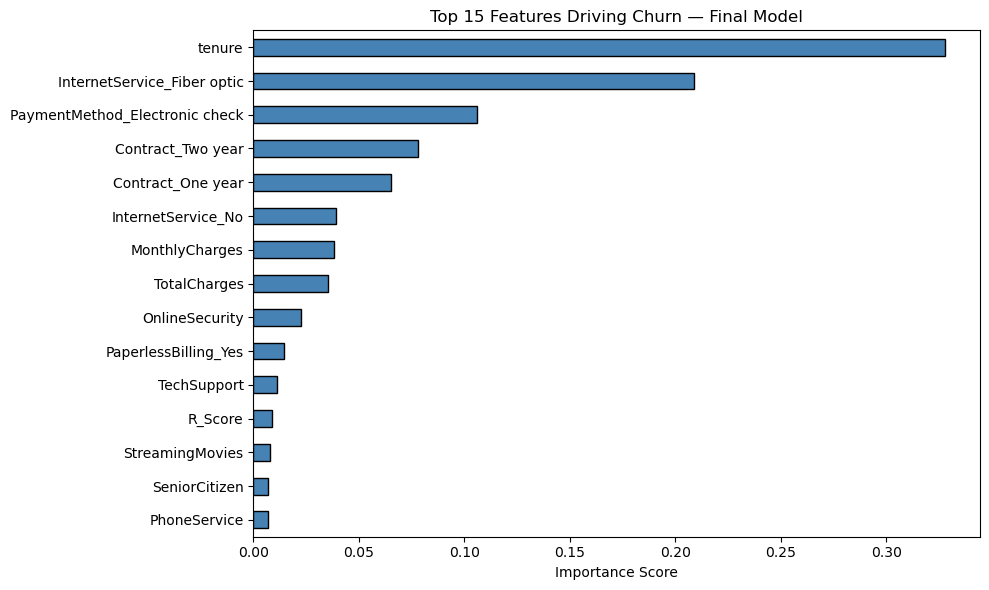

Top 5 churn drivers:
tenure                            0.328048
InternetService_Fiber optic       0.208859
PaymentMethod_Electronic check    0.106205
Contract_Two year                 0.077839
Contract_One year                 0.065028
dtype: float64


In [15]:
# Get importance scores from our final Gradient Boosting model
# In GB, feature_importances_ shows how much each feature reduced prediction error
importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Features Driving Churn — Final Model')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r'C:\Users\Janhavi\ChurnProject\reports\feature_importance.png')
plt.show()

print("Top 5 churn drivers:")
print(importances.head(5))


In [16]:
# Save our final Gradient Boosting model
with open(r'C:\Users\Janhavi\ChurnProject\models\best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("✅ Final Gradient Boosting model saved!")
print("ROC-AUC: 0.8414 — this is what our web app will use.")


✅ Final Gradient Boosting model saved!
ROC-AUC: 0.8414 — this is what our web app will use.
